# Data Exploration

Before building any model, we need to answer a fundamental question about our data: Are there any learnable patterns?

Machine learning models extract patterns from data. Without meaningful patterns, the model will fail to make useful predictions.

As we explore the data, we'll continuously evaluate whether predictive signals exist and where they might be found.

## Data Sources

All datasets used come from the United States Department of Transportation's [Airline On-Time Performance Data](https://transtats.bts.gov/DatabaseInfo.asp?QO_VQ=EFD&DB_URL=). To maintain reasonable performance, this notebook will only use at the first 4 months of the year.

In [57]:
import pandas as pd
import os

#list of datasets
csv_files = ['../data/raw/jan_2025_ontime.csv', '../data/raw/feb_2025_ontime.csv', '../data/raw/mar_2025_ontime.csv', '../data/raw/apr_2025_ontime.csv']

# 2. Loop and Load
df_list = []
for filename in csv_files:
    print(f"Reading {filename}...")

    temp_df = pd.read_csv(filename)
    
    df_list.append(temp_df)

# 3. Concatenate (The Merge)
print("Merging dataframes...")
df = pd.concat(df_list, ignore_index=True)

print(f"Loaded {df.shape[0]} rows.")
print("Columns: \n", list(df.columns))




Reading ../data/raw/jan_2025_ontime.csv...
Reading ../data/raw/feb_2025_ontime.csv...
Reading ../data/raw/mar_2025_ontime.csv...
Reading ../data/raw/apr_2025_ontime.csv...
Merging dataframes...
Loaded 2229453 rows.
Columns: 
 ['YEAR', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID', 'DEST', 'CRS_DEP_TIME', 'DEP_DELAY', 'DEP_DEL15', 'CRS_ARR_TIME', 'ARR_DELAY', 'ARR_DEL15', 'CANCELLED', 'DIVERTED', 'DISTANCE']


## Late, Cancelled, Diverted
Here's a simple starting question: **Exlcuding cancelled and diverted flights**, in total, how many flights were late and how many were on time?

In [58]:
df_clean = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()

print(f"Original Rows: {len(df)}")
print(f"Clean Rows (Actual Flights): {len(df_clean)}")
print(f"Dropped: {len(df) - len(df_clean)} flights that never made it.")

Original Rows: 2229453
Clean Rows (Actual Flights): 2188776
Dropped: 40677 flights that never made it.


In [59]:
# The FAA defines "late" as 15 minutes or more. 
# The dataset has a column 'ARR_DEL15' that acts as a flag for if a flight was late.

on_time_count = df_clean[df_clean['ARR_DEL15'] == 0].shape[0]
late_count = df_clean[df_clean['ARR_DEL15'] == 1].shape[0]

total_flights = len(df_clean)
percent_late = (late_count / total_flights) * 100

print(f"On Time Flights: {on_time_count} ({(on_time_count/total_flights)*100:.2f}%)")
print(f"Late Flights:    {late_count} ({percent_late:.2f}%)")

On Time Flights: 1757906 (80.31%)
Late Flights:    430870 (19.69%)


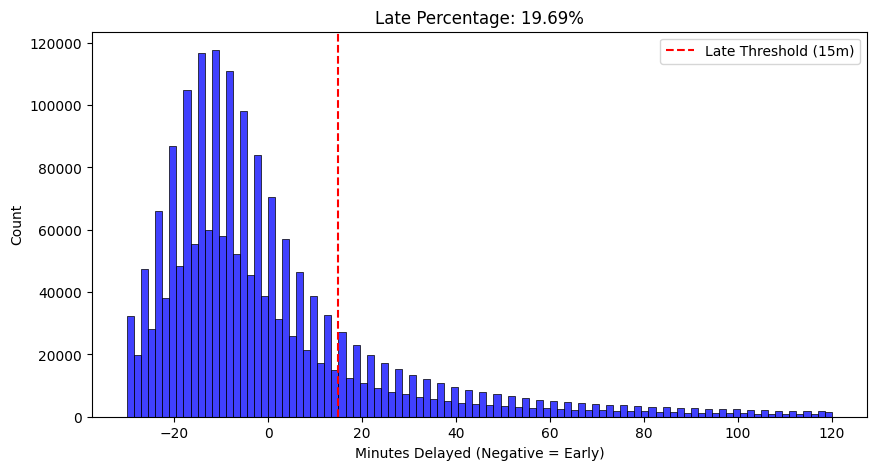

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# We use a histogram to see the shape of the delays
# We limit the view to -30 to +120 minutes to zoom in on the "Battleground"
sns.histplot(df_clean['ARR_DELAY'], bins=100, binrange=(-30, 120), color='blue')

# Draw the "Late Line" at 15 minutes
plt.axvline(15, color='red', linestyle='--', label='Late Threshold (15m)')

plt.title(f"Late Percentage: {percent_late:.2f}%")
plt.xlabel("Minutes Delayed (Negative = Early)")
plt.legend()
##plt.show()

## Interesting thought

A program that simply says "flight will be On Time" for every single flight in this dataset, will be right 80.31% of the time.

A "useful" model will need to beat 80.31%. Otherwise we might as well stick to using our simple program!

## Airlines

Let's look at our data on the airlines. How many carriers are there? how many flights did they do? how many of them were late? What is the percentage? 

In [61]:
carrier_stats = df_clean.groupby('OP_UNIQUE_CARRIER')['ARR_DEL15'].agg(['count', 'sum', 'mean']).reset_index()

# 2. Rename columns for readability
carrier_stats.columns = ['Carrier', 'Total_Flights', 'Late_Flights', 'Late_Pct']

# 3. Convert Mean to Percentage (0.18 -> 18.0)
carrier_stats['Late_Pct'] = carrier_stats['Late_Pct'] * 100

# 5. PRINT THE NUMBERS
print(f"Total Carriers Found: {len(carrier_stats)}")
print("\n--- Carrier Performance ---")

display(carrier_stats)

Total Carriers Found: 14

--- Carrier Performance ---


,Carrier,Total_Flights,Late_Flights,Late_Pct
0,AA,302790,66504.0,21.963737
1,AS,71431,13620.0,19.067352
2,B6,75680,17492.0,23.113108
3,DL,312503,58789.0,18.812299
4,F9,65965,16951.0,25.696961
5,G4,42596,9724.0,22.828435
6,HA,25707,4226.0,16.439102
7,MQ,87416,17423.0,19.931134
8,NK,70759,12844.0,18.151755
9,OH,78476,21885.0,27.887507


/tmp/ipykernel_727111/1796893204.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=carrier_stats, x='Carrier', y='Late_Pct', palette='coolwarm')
/tmp/ipykernel_727111/1796893204.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


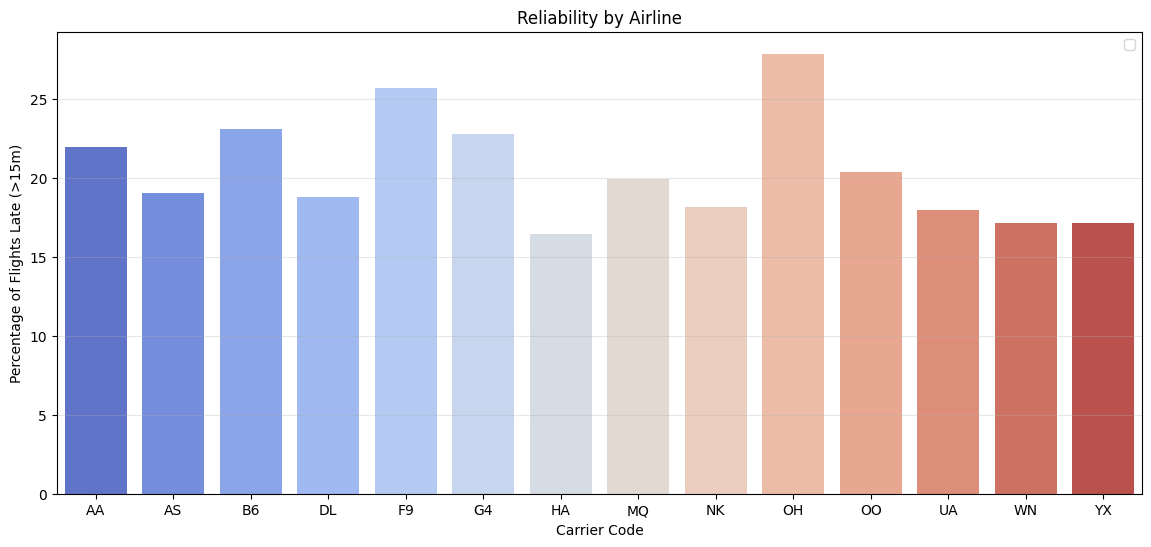

In [62]:
plt.figure(figsize=(14, 6))
# Bar chart of Late Percentage
sns.barplot(data=carrier_stats, x='Carrier', y='Late_Pct', palette='coolwarm')

# Add the average line for context
avg_late = carrier_stats['Late_Flights'].sum() / carrier_stats['Total_Flights'].sum() * 100

plt.title("Reliability by Airline")
plt.ylabel("Percentage of Flights Late (>15m)")
plt.xlabel("Carrier Code")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## Weekdays

What days of the week had the most late flights?


--- Performance by Day of Week ---


,Day_Name,Day_Num,Total_Flights,Late_Flights,Late_Pct
0,Mon,1,324952,69257.0,21.312994
1,Tue,2,291796,41998.0,14.392932
2,Wed,3,312350,54380.0,17.409957
3,Thu,4,325978,70612.0,21.661585
4,Fri,5,327283,66146.0,20.210643
5,Sat,6,283773,54530.0,19.216064
6,Sun,7,322644,73947.0,22.919069


/tmp/ipykernel_727111/2096241340.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_stats, x='Day_Name', y='Late_Pct', palette='magma')
/tmp/ipykernel_727111/2096241340.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


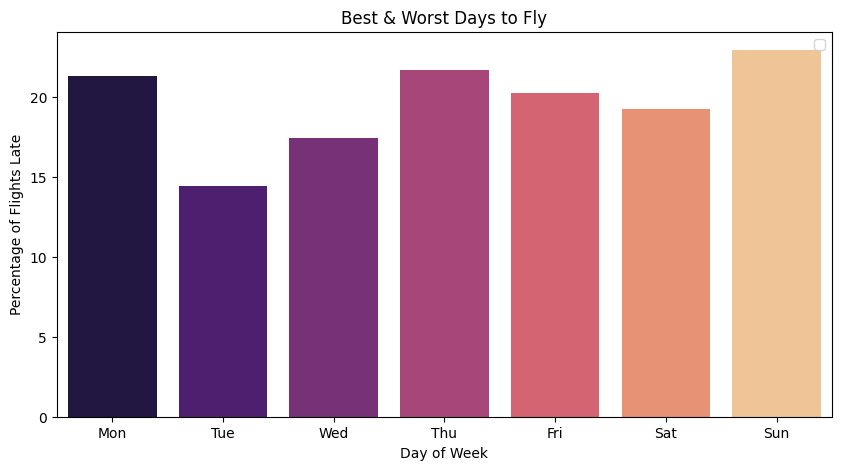

In [63]:
# Group by Day of Week (1=Monday, 7=Sunday)
day_stats = df_clean.groupby('DAY_OF_WEEK')['ARR_DEL15'].agg(['count', 'sum', 'mean']).reset_index()

# 2. Rename columns
day_stats.columns = ['Day_Num', 'Total_Flights', 'Late_Flights', 'Late_Pct']

# 3. Convert to Percentage
day_stats['Late_Pct'] = day_stats['Late_Pct'] * 100

# 4. Map Numbers to Names for readability (DOT Standard: 1=Mon, 7=Sun)
day_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
day_stats['Day_Name'] = day_stats['Day_Num'].map(day_map)

# 5. PRINT THE NUMBERS
print("\n--- Performance by Day of Week ---")
# Reorder columns to put Name first
display(day_stats[['Day_Name', 'Day_Num', 'Total_Flights', 'Late_Flights', 'Late_Pct']])

plt.figure(figsize=(10, 5))
sns.barplot(data=day_stats, x='Day_Name', y='Late_Pct', palette='magma')

# Add the national average line again for comparison
avg_late = df_clean['ARR_DEL15'].mean() * 100

plt.title("Best & Worst Days to Fly")
plt.ylabel("Percentage of Flights Late")
plt.xlabel("Day of Week")
plt.legend()
plt.show()

## Flight Routes
Which flight routes had the highest percentage of late flights overall? 

In [64]:
# 1. Create a "Route" string for easier reading
df_clean['Route'] = df_clean['ORIGIN'] + " -> " + df_clean['DEST']

# 2. Calculate Stats by Route
route_stats = df_clean.groupby('Route')['ARR_DEL15'].agg(['count', 'sum', 'mean']).reset_index()
route_stats.columns = ['Route', 'Total_Flights', 'Late_Flights', 'Late_Pct']
route_stats['Late_Pct'] = route_stats['Late_Pct'] * 100

# 3. THE FILTER (Critical Step)
# We only care about routes with enough data (e.g., > 30 flights in the month)
# Otherwise, we get 100% late rates from single flights.
min_flights = 30
popular_routes = route_stats[route_stats['Total_Flights'] >= min_flights].copy()

# 4. Sort Extremes
# The "Hall of Shame" (Worst Routes)
worst_routes = popular_routes.sort_values('Late_Pct', ascending=False).head(10)
# The "Hall of Fame" (Best Routes)
best_routes = popular_routes.sort_values('Late_Pct', ascending=True).head(10)

# 5. PRINT THE NUMBERS
print(f"Total Unique Routes: {len(route_stats)}")
print(f"Routes with >{min_flights} flights: {len(popular_routes)}")

print("\n--- 10 Most Reliable Routes (Lowest Delay %) ---")
display(best_routes[['Route', 'Total_Flights', 'Late_Pct']])

print("\n--- 10 Least Reliable Routes (Highest Delay %) ---")
display(worst_routes[['Route', 'Total_Flights', 'Late_Pct']])

Total Unique Routes: 6045
Routes with >30 flights: 5435

--- 10 Most Reliable Routes (Lowest Delay %) ---


,Route,Total_Flights,Late_Pct
5289,SFB -> MFE,34,0.000000
393,AZA -> FWA,32,0.000000
2927,LAS -> FAR,56,0.000000
2911,LAS -> CHA,33,0.000000
390,AZA -> FCA,39,0.000000
4366,PGD -> PBG,46,2.173913
5947,TUS -> SLC,359,2.785515
2697,IND -> JAX,34,2.941176
4355,PGD -> IAD,34,2.941176
5704,SRQ -> SDF,34,2.941176



--- 10 Least Reliable Routes (Highest Delay %) ---


,Route,Total_Flights,Late_Pct
4898,ROA -> SFB,41,73.170732
5840,TOL -> SFB,49,71.428571
5302,SFB -> ROA,41,68.292683
3139,LEX -> SFB,47,68.085106
5308,SFB -> TOL,50,64.000000
880,CHA -> DCA,82,62.195122
5164,SDF -> SFB,34,61.764706
5285,SFB -> LEX,47,59.574468
5304,SFB -> SDF,34,58.823529
935,CKB -> SFB,33,57.575758


## Time of Day

How lateness spread across the time of day?

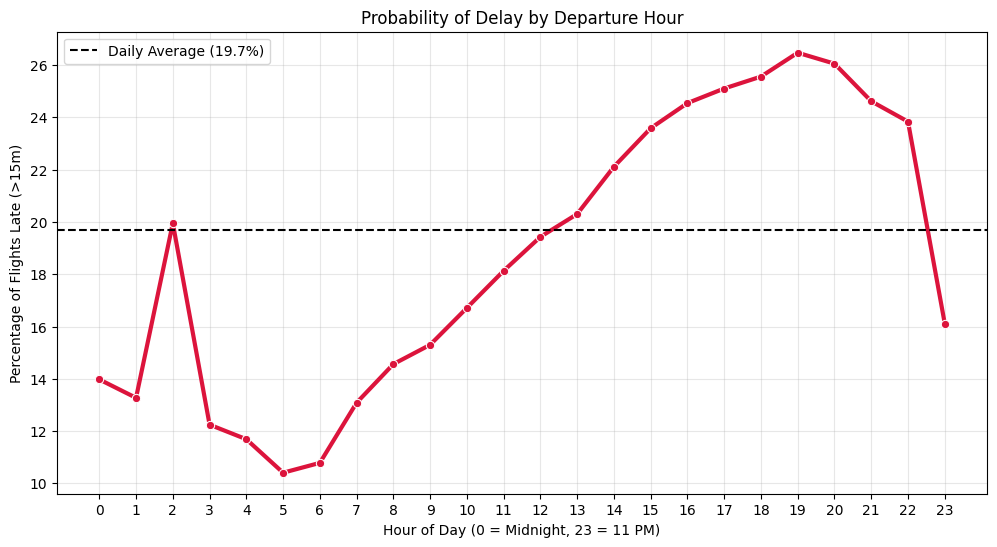

Late % at 6:00 AM:  10.8%
Late % at 7:00 PM:  26.5%


In [65]:
# 1. Feature Engineering (Temporary for this visual)
# Convert 1430 -> 14 (Hour of Day)
df_clean['Dep_Hour'] = df_clean['CRS_DEP_TIME'] // 100

# 2. Aggregation
# We want to know the Late % for every single hour of the day
hourly_stats = df_clean.groupby('Dep_Hour')['ARR_DEL15'].mean().reset_index()
# Convert to percentage
hourly_stats['Late_Pct'] = hourly_stats['ARR_DEL15'] * 100

# 3. Visualization
plt.figure(figsize=(12, 6))

# We use a line plot because time is continuous
sns.lineplot(data=hourly_stats, x='Dep_Hour', y='Late_Pct', marker='o', color='crimson', linewidth=3)

# Add a reference line for the daily average
avg_late = df_clean['ARR_DEL15'].mean() * 100
plt.axhline(avg_late, color='black', linestyle='--', label=f'Daily Average ({avg_late:.1f}%)')

plt.title("Probability of Delay by Departure Hour")
plt.xlabel("Hour of Day (0 = Midnight, 23 = 11 PM)")
plt.ylabel("Percentage of Flights Late (>15m)")
plt.xticks(range(0, 24)) # Show every hour
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Print the extreme difference
morning_late = hourly_stats[hourly_stats['Dep_Hour'] == 6]['Late_Pct'].values[0]
evening_late = hourly_stats[hourly_stats['Dep_Hour'] == 19]['Late_Pct'].values[0]
print(f"Late % at 6:00 AM:  {morning_late:.1f}%")
print(f"Late % at 7:00 PM:  {evening_late:.1f}%")

--- Top 50 Busiest Airports: Reliability Ranking ---


,Airport,Total_Flights,Late_Pct
173,LAX,60359,14.534701
294,SLC,37686,15.666295
285,SFO,44412,15.826804
238,PHX,68328,16.454455
171,LAS,61060,17.461513
283,SEA,47480,18.291912
216,MSP,34568,18.329090
149,IAH,36317,19.439932
193,MCO,54196,19.826186
182,LGA,42639,20.879946


/tmp/ipykernel_727111/2679778032.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ranked_airports, y='Airport', x='Late_Pct', palette='coolwarm')


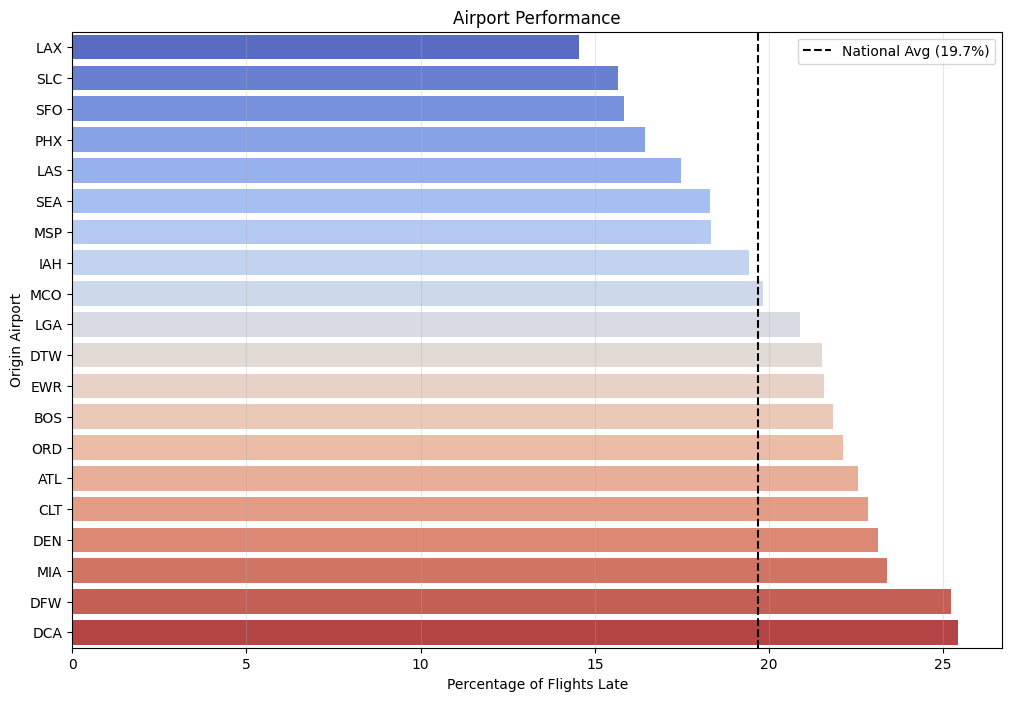

In [66]:
# 1. Calculate Stats by Origin
airport_stats = df_clean.groupby('ORIGIN')['ARR_DEL15'].agg(['count', 'mean']).reset_index()
airport_stats.columns = ['Airport', 'Total_Flights', 'Late_Pct']
airport_stats['Late_Pct'] = airport_stats['Late_Pct'] * 100

# 2. THE FILTER: Top 20 Busiest Airports only
# We sort by volume first to get the major hubs
top_20_airports = airport_stats.sort_values('Total_Flights', ascending=False).head(20)

# 3. THE SORT: Rank them by Reliability (Best to Worst)
ranked_airports = top_20_airports.sort_values('Late_Pct', ascending=True)

# 4. PRINT THE DATA
print("--- Top 50 Busiest Airports: Reliability Ranking ---")
display(ranked_airports)

# 5. VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(data=ranked_airports, y='Airport', x='Late_Pct', palette='coolwarm')

# Add the National Average line
avg_late = df_clean['ARR_DEL15'].mean() * 100
plt.axvline(avg_late, color='black', linestyle='--', label=f'National Avg ({avg_late:.1f}%)')

plt.title("Airport Performance")
plt.xlabel("Percentage of Flights Late")
plt.ylabel("Origin Airport")
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.show()

## Conclusion

There are a lot more views we could explore on the data. But this notebook will stop here.

So are there patterns in our data that a machine learning model could discover? It seems like it!